# 02 — EDA: Medical Abstracts TC Corpus

**Objetivo desta análise:**

1. Entender estrutura, classes e qualidade dos dados. 
2. Detectar duplicidade e risco de data leakage entre os splits originais. 
3. Definir e justificar a regra de mapeamento das 5 classes de condição médica para as 3
classes de urgência exigidas pelo desafio (normal / atenção / urgente).
4. Produzir um dataset processado, sem leakage, pronto para a etapa de modelagem. 


In [22]:
%matplotlib inline
import json
import os
import platform

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110

print(f"python       {platform.python_version()}")
print(f"pandas       {pd.__version__}")
print(f"numpy        {np.__version__}")
print(f"scikit-learn {sklearn.__version__}")
print(f"RANDOM_STATE = {RANDOM_STATE}")


python       3.11.15
pandas       3.0.5
numpy        1.26.4
scikit-learn 1.9.0
RANDOM_STATE = 42


In [23]:
pd.set_option("display.max_colwidth", 120)

train = pd.read_parquet("../data/experiments/medical_abstracts/train.parquet")
test = pd.read_parquet("../data/experiments/medical_abstracts/test.parquet")
labels = pd.read_parquet("../data/experiments/medical_abstracts/labels.parquet")

print("train:", train.shape, "| test:", test.shape)
labels

train: (11550, 2) | test: (2888, 2)


,condition_label,condition_name
0,1,neoplasms
1,2,digestive system diseases
2,3,nervous system diseases
3,4,cardiovascular diseases
4,5,general pathological conditions


## 1. Estrutura e classes

In [24]:
train.head(3)

,condition_label,medical_abstract
0,5,Tissue changes around loose prostheses. A canine model to investigate the effects of an antiinflammatory agent. The ...
1,1,Neuropeptide Y and neuron-specific enolase levels in benign and malignant pheochromocytomas. Neuron-specific enolase...
2,2,"Sexually transmitted diseases of the colon, rectum, and anus. The challenge of the nineties. During the past two dec..."


In [25]:
train["condition_label"].value_counts().sort_index()

condition_label
1    2530
2    1195
3    1540
4    2441
5    3844
Name: count, dtype: int64

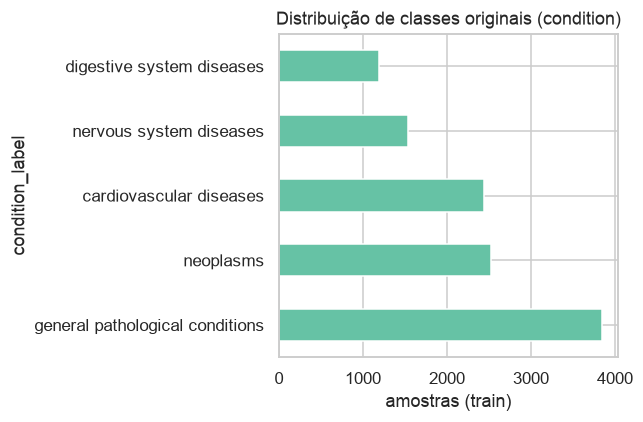

In [26]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = train["condition_label"].map(labels.set_index("condition_label")["condition_name"]).value_counts()
counts.plot(kind="barh", ax=ax)
ax.set_xlabel("amostras (train)")
ax.set_title("Distribuição de classes originais (condition)")
plt.tight_layout()
plt.savefig("../docs/ml/assets_class_distribution.png", dpi=110)
plt.show()

## 2. Qualidade dos dados: nulos, tamanho de texto, duplicidade

In [33]:
print("Nulos (train): ", train.isnull().sum().to_dict())
print("Nulos (test): ", test.isnull().sum().to_dict())

word_counts = train["medical_abstract"].str.split().str.len()
print(word_counts.describe())

Nulos (train):  {'condition_label': 0, 'medical_abstract': 0}
Nulos (test):  {'condition_label': 0, 'medical_abstract': 0}
count    11550.000000
mean       179.640606
std         76.369776
min         24.000000
25%        122.000000
50%        175.000000
75%        234.000000
max        596.000000
Name: medical_abstract, dtype: float64


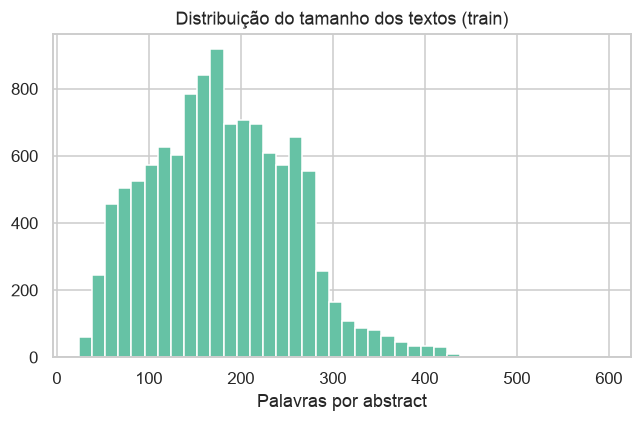

In [34]:
fig, ax = plt.subplots(figsize=(6, 4))
word_counts.hist(bins=40, ax=ax)
ax.set_xlabel("Palavras por abstract")
ax.set_title("Distribuição do tamanho dos textos (train)")
plt.tight_layout()
plt.savefig("../docs/ml/assets_text_length.png", dpi=110)
plt.show()

In [35]:
dup_within_train = train["medical_abstract"].duplicated().sum()
overlap = set(train["medical_abstract"]) & set(test["medical_abstract"])
print("Duplicatas exatas dentro do train:", dup_within_train)
print("Textos que aparecem em train E test simultaneamente:", len(overlap))
print(f"Isso representa {len(overlap) / len(test):.1%} do split de test original.")

Duplicatas exatas dentro do train: 2105
Textos que aparecem em train E test simultaneamente: 988
Isso representa 34.2% do split de test original.


**Achados críticos de data leakage**: o split train/test original do dataset publicado contém textos idênticos em ambos os lados (quase 1 em cada 3 exemplos do split de teste também aparece no treino). Avaliar o modelo nesse split "oficial" inflaria artificialmente as métricas. 

Além disso, textos idênticos aparecem sob rótulos de condição diferentes (abstracts que tocam mais de uma especialidade, mas o dataset é single-label) - um limite conhecido deste corpus.

**Decisão**: descartar os splits originais, concatenear train+test, remover duplicatas exatas de texto (mantendo a primeira ocorrência) e gerar um split próprio, estratificado, a partir do conjunto deduplicado. Isso elimina o vazamento entre treino e teste. 

In [36]:
combined = pd.concat([train, test], ignore_index=True)
before = len(combined)
combined = combined.drop_duplicates(subset=["medical_abstract"]).reset_index(drop=True)
after = len(combined)
print(f"Registros antes da deduplicação: {before}")
print(f"Registros após deduplicação: {after} ({before - after} duplicatas removidas)")
combined["condition_label"].value_counts().sort_index()

Registros antes da deduplicação: 14438
Registros após deduplicação: 11227 (3211 duplicatas removidas)


condition_label
1    2657
2    1084
3    1445
4    2483
5    3558
Name: count, dtype: int64

## 3. Mapeamento de classes de condição → classes de urgência

* O corpus rotula o **tipo de condição médica** discutida no
abstract, não a urgência clínica de um caso individual — não existe rótulo de urgência real
neste dataset. Para viabilizar o desafio (classificação de laudo em normal/atenção/urgente)
aplicamos uma heurística simples e documentada, e explicitamente NÃO a apresentamos como
protocolo de triagem clínica validado:

| Classe de condição original | Classe de urgência mapeada | Racional |
|---|---|---|
| Cardiovascular diseases | **urgente** | Eventos cardiovasculares (IAM, arritmias, AVC de origem cardíaca) são tipicamente tempo-críticos. |
| Nervous system diseases | **urgente** | Sintomas neurológicos agudos (AVC, convulsão, alteração de consciência) exigem avaliação rápida. |
| Neoplasms | **atenção** | Requer investigação e acompanhamento, mas raramente é uma emergência imediata. |
| Digestive system diseases | **atenção** | Espectro amplo de gravidade; tratado como prioridade intermediária por padrão. |
| General pathological conditions | **normal** | Categoria residual/inespecífica do corpus — tratada como linha de base de menor prioridade. |

**Limitação explícita**: esta é uma aproximação para fins do desafio técnico, não uma
classificação clínica validada por especialistas. Em um cenário real, os rótulos de urgência
deveriam ser definidos e validados por profissionais de saúde.


In [37]:
URGENCY_MAP = {
    4: "urgente",    # cardiovascular diseases
    3: "urgente",    # nervous system diseases
    1: "atencao",    # neoplasms
    2: "atencao",    # digestive system diseases
    5: "normal",     # general pathological conditions
}

combined["urgency"] = combined["condition_label"].map(URGENCY_MAP)
combined["urgency"].value_counts()

urgency
urgente    3928
atencao    3741
normal     3558
Name: count, dtype: int64

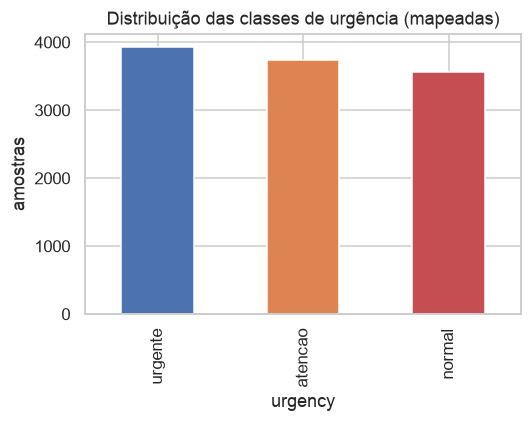

In [38]:
fig, ax = plt.subplots(figsize=(5, 4))
combined["urgency"].value_counts().plot(kind="bar", ax=ax, color=["#4c72b0", "#dd8452", "#c44e52"])
ax.set_title("Distribuição das classes de urgência (mapeadas)")
ax.set_ylabel("amostras")
plt.tight_layout()
plt.savefig("../docs/ml/assets_urgency_distribution.png", dpi=110)
plt.show()

Classes ficaram razoavelmente balanceadas (~32-35% cada) — não é necessário balanceamento
sintético (SMOTE/undersampling); `class_weight="balanced"` nos modelos é suficiente como
salvaguarda.


## 4. Split estratificado (sem leakage) e persistência

In [39]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    combined[["medical_abstract", "urgency"]],
    test_size=0.2,
    stratify=combined["urgency"],
    random_state=42,
)

print("train:", train_df.shape, "test:", test_df.shape)
assert set(train_df["medical_abstract"]) & set(test_df["medical_abstract"]) == set(), "leakage detectado!"
print("Sem overlap de texto entre train/test: OK")

train_df.to_csv("../data/processed/train.csv", index=False)
test_df.to_csv("../data/processed/test.csv", index=False)
print("Salvo em data/processed/train.csv e test.csv")

train: (8981, 2) test: (2246, 2)
Sem overlap de texto entre train/test: OK


OSError: Cannot save file into a non-existent directory: '../data/processed'

## Conclusão da EDA

- Dataset final (deduplicado): **11.227 abstracts únicos**, muito acima do mínimo de 2.000 exigido.
- Sem valores nulos.
- Textos de tamanho moderado (mediana ~175 palavras) — compatível com TF-IDF clássico, sem
  necessidade de truncamento agressivo.
- Vazamento entre splits identificado e corrigido via deduplicação + re-split estratificado.
- Classes de urgência mapeadas ficam balanceadas, então accuracy simples já é uma métrica
  razoável, mas ainda assim reportaremos macro-F1 e recall da classe `urgente` (classe crítica)
  como critérios principais — ver `docs/ml/model-comparison.md`.
